# Phương thức triển khai
1. Chuẩn hoá dữ liệu âm thanh
~~~
normalized_audio = audio_data.astype(float)
normalized_audio = normalized_audio / np.max(np.abs(normalized_audio))
~~~
Chuẩn hóa biên độ tín hiệu về khoảng [-1, 1] bằng cách chia cho giá trị tuyệt đối lớn nhất  
Chú thích: 
- Tránh tràn số (Overflow) và mất dữ liệu (Underflow)	chuyển từ `int` sang `float` để tránh lỗi làm tròn và sai số.
- Đưa tín hiệu về phạm vi [-1, 1]	giúp tín hiệu có biên độ đồng nhất, bất kể dữ liệu gốc có giá trị thế nào.
- Các thuật toán như FFT, HPS làm việc chính xác hơn khi dữ liệu nằm trong khoảng [-1, 1].

2. Windowing sử dụng Hanning
```
window = np.hanning(len(normalized_audio))
windowed_signal = normalized_audio * window
```
Giảm rò rì phổ (spectral leakage)  
Chú thích:
- tín hiệu thu vào là hữu hạn và thường không tuần hoàn, 2 đoạn đầu cuối có thể không khớp, khi FFT lặp lại tín hiệu sẽ bị nhảy đột ngột, gây nhiễu
- windowing làm giảm biên độ tín hiệu ở 2 đầu về gần 0, hạn chế nhiễu

3. FFT
~~~
freq_spectrum = np.abs(rfft(windowed_signal))
~~~
Chuyển tín hiệu từ miền thời gian sang miền tần số

4. Nội suy
~~~
interpolated_magnitude_spectrum = np.interp(
            np.arange(0, len(freq_spectrum), 1 / NUM_HPS),  # x_new
            np.arange(0, len(freq_spectrum)),  # x_old
            freq_spectrum,  # y_old
        )
~~~
Lấy mẫu lại phổ tần số với độ phân giải cao hơn để phục vụ cho Harmonic Product Spectrum (HPS)  

5. Chuẩn hoá phổ đã nội suy
~~~
interpolated_magnitude_spectrum = (
            interpolated_magnitude_spectrum
            / np.linalg.norm(interpolated_magnitude_spectrum, ord=2)
        )
~~~
Chuẩn hoá về phạm vi [0,1] để phục vụ cho HPS

6. HPS
~~~
hps_spec = copy.deepcopy(interpolated_magnitude_spectrum)
for i in range(1, NUM_HPS):
    # Get the first segment of hps_spec up to length/harmonic
    a = hps_spec[: int(np.ceil(len(interpolated_magnitude_spectrum) / (i + 1)))]

    # Get every (i+1)th sample from interpolated spectrum for harmonic comparison
    b = interpolated_magnitude_spectrum[:: (i + 1)]

    temp_hps_spec = np.multiply(a, b)

    if not any(temp_hps_spec):
        break
    hps_spec = temp_hps_spec
~~~
HPS (Harmonic Product Spectrum) là một kỹ thuật được sử dụng để tìm tần số cơ bản của một tín hiệu bằng cách nhân phổ tần số với các phiên bản thu nhỏ của chính nó.  

✅ Mục tiêu là tăng cường tần số cơ bản (fundamental frequency) và giảm nhiễu từ các hài âm(harmonics)/bội âm(overtunes) của nó.  
![markdown](http://sv.mazurka.org.uk/MzHarmonicSpectrum/img/hpsdiagram.png)

## 📌 Giả sử có một tín hiệu với phổ tần số ban đầu

| Index (Tần số) | 0  | 1  | 2  | 3  | 4  | 5  | 6  | 7  | 8  | 9  |
|---------------|----|----|----|----|----|----|----|----|----|----|
| Biên độ FFT  | 10 | 50 | 80 | 100| 70 | 40 | 30 | 20 | 10 | 5  |

Giả sử **NUM_HPS = 3**, tức là ta sẽ nhân phổ tần số gốc với 2 phiên bản giảm bậc của nó.

---

### 🔹 Bước 1: HPS Bậc 2 (i = 1)  

- **Lấy phần đầu của `hps_spec` (chỉ lấy 1/2 đầu mảng):**  

| Index | 0  | 1   | 2  | 3   | 4  |
|-------|----|-----|----|-----|----|
| `a`  | 10 | 50  | 80 | 100 | 70 |

- **Lấy mỗi phần tử thứ 2 trong `interpolated_magnitude_spectrum` để nhân:**  

| Index | 0  | 1  | 2  | 3  | 4  |
|-------|----|----|----|----|----|
| `b`  | 10 | 80 | 70 | 30 | 10 |

- **Nhân từng phần tử:**  

| Index | 0   | 1    | 2   | 3    | 4   |
|-------|-----|------|-----|------|-----|
| `hps_spec` | 100 | 4000 | 5600 | 3000 | 700 |

---

### 🔹 Bước 2: HPS Bậc 3 (i = 2)  

- **Lấy phần đầu của `hps_spec` (chỉ lấy 1/3 đầu mảng):**  

| Index | 0    | 1     | 2    |
|-------|------|-------|------|
| `a`  | 100  | 4000  | 5600 |

- **Lấy mỗi phần tử thứ 3 trong `interpolated_magnitude_spectrum` để nhân:**  

| Index | 0  | 1    | 2  |
|-------|----|------|----|
| `b`  | 10 | 100  | 30 |

- **Nhân từng phần tử:**  

| Index | 0    | 1      | 2     |
|-------|------|--------|-------|
| `hps_spec` | 1000 | 400000 | 168000 |

---

### 🔹 Kết quả cuối cùng  
Sau khi thực hiện HPS, giá trị lớn nhất trong `hps_spec` xuất hiện tại **index = 1**


## DFT Plot

absFreqSpectrum: [[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 0.]]
highest amplitude: 16720.0
highest amplitude index: 7602
highest amplitude frequency: 1689.3333333333333


/var/folders/qk/pz9gz5ds2gz27n9rkfdv84_m0000gn/T/ipykernel_89784/3831222235.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")


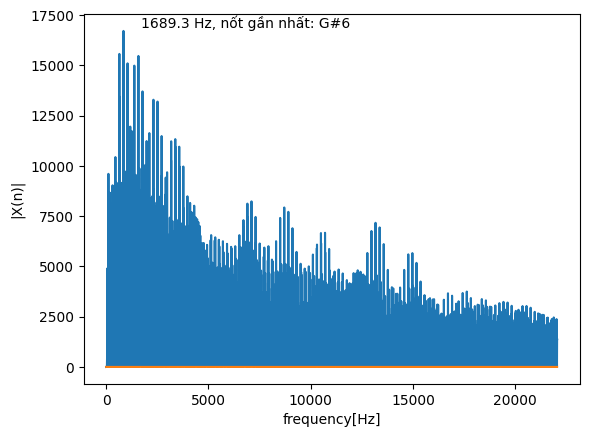

In [5]:
import scipy.io.wavfile
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import fft

CONCERT_PITCH = 440
ALL_NOTES = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]


def find_closest_note(pitch):
    i = int(np.round(np.log2(pitch / CONCERT_PITCH) * 12))
    closest_note = ALL_NOTES[i % 12] + str(4 + (i + 9) // 12)
    closest_pitch = CONCERT_PITCH * 2 ** (i / 12)
    return closest_note, closest_pitch


# sampleFreq, myRecording = scipy.io.wavfile.read("Guitar Dataset/F5/F5-1-spn.wav")
sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")

sampleDur = len(myRecording) / sampleFreq
timeX = np.arange(0, sampleFreq / 2, sampleFreq / len(myRecording))
absFreqSpectrum = abs(fft(myRecording))

print("absFreqSpectrum:", absFreqSpectrum)
highest_amplitude = np.max(absFreqSpectrum)
highest_amplitude_index = np.argmax(absFreqSpectrum)
highest_amplitude_frequency = timeX[highest_amplitude_index]
print("highest amplitude:", highest_amplitude)
print("highest amplitude index:", highest_amplitude_index)
print("highest amplitude frequency:", highest_amplitude_frequency)

# Add text label showing peak frequency
plt.text(
    highest_amplitude_frequency,
    highest_amplitude,
    f"{highest_amplitude_frequency:.1f} Hz, nốt gần nhất: {find_closest_note(highest_amplitude_frequency)[0]}",
    horizontalalignment="left",
    verticalalignment="bottom",
)


plt.plot(timeX, absFreqSpectrum[: len(myRecording) // 2])
plt.ylabel("|X(n)|")
plt.xlabel("frequency[Hz]")
plt.show()

## HPS Plot

/var/folders/qk/pz9gz5ds2gz27n9rkfdv84_m0000gn/T/ipykernel_89784/4100517565.py:40: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")


Tần số cơ bản phát hiện được: 146.67 Hz
Nốt gần nhất: D4 (293.66 Hz)
Lệch: 26 cents, Dễ nhận ra, âm nghe bị lệch.
Cần hạ dây


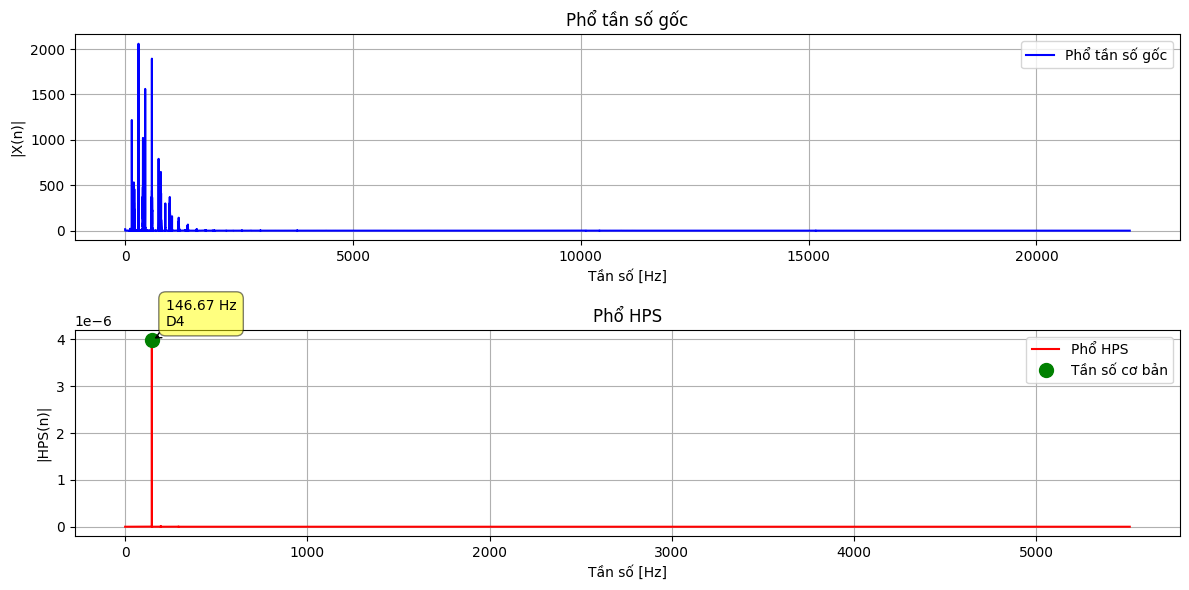

In [ ]:
import scipy.io.wavfile
import matplotlib.pyplot as plt
import numpy as np
from scipy.fftpack import fft
import copy

CONCERT_PITCH = 440
ALL_NOTES = ["A", "A#", "B", "C", "C#", "D", "D#", "E", "F", "F#", "G", "G#"]
NUM_HPS = 4  # Số lượng hài âm để tính HPS

# Bảng tham chiếu độ lệch cents
CENTS_REFERENCE = {
    (0, 0): "Hoàn toàn đúng nốt. 🎯",
    (1, 5): "Gần như không thể nghe thấy.",
    (5, 20): "Người có tai tốt có thể nhận ra.",
    (20, 50): "Dễ nhận ra, âm nghe bị lệch.",
    (50, float("inf")): "Nghe như một nốt khác. 🎵",
}


def get_cents_description(cents):
    """Trả về mô tả dựa trên độ lệch cents"""
    abs_cents = abs(cents)
    for (lower, upper), description in CENTS_REFERENCE.items():
        if lower <= abs_cents < upper:
            return description
    return CENTS_REFERENCE[(50, float("inf"))]


def find_closest_note(pitch):
    i = int(np.round(np.log2(pitch / CONCERT_PITCH) * 12))
    closest_note = ALL_NOTES[i % 12] + str(4 + (i + 9) // 12)
    closest_pitch = CONCERT_PITCH * 2 ** (i / 12)
    # Calculate cents difference
    cents = 1200 * np.log2(pitch / closest_pitch)
    return closest_note, closest_pitch, cents


# Đọc file âm thanh
sampleFreq, myRecording = scipy.io.wavfile.read("D3.wav")

# Xử lý stereo/mono
if len(myRecording.shape) > 1:  # Nếu là stereo
    myRecording = myRecording.mean(axis=1)  # Chuyển sang mono bằng cách lấy trung bình

# Chuẩn hóa dữ liệu
myRecording = myRecording.astype(float)
myRecording = myRecording / np.max(np.abs(myRecording))

# Tính thời gian và tần số
sampleDur = len(myRecording) / sampleFreq
timeX = np.arange(0, sampleFreq / 2, sampleFreq / len(myRecording))

# Áp dụng cửa sổ Hanning
window = np.hanning(len(myRecording))
windowed_signal = myRecording * window

# Tính FFT
absFreqSpectrum = abs(fft(windowed_signal))
freqSpectrum = absFreqSpectrum[: len(myRecording) // 2]

# Nội suy phổ tần số
mag_spec_ipol = np.interp(
    np.arange(0, len(freqSpectrum), 1 / NUM_HPS),
    np.arange(0, len(freqSpectrum)),
    freqSpectrum,
)

# Chuẩn hóa phổ
mag_spec_ipol = mag_spec_ipol / np.linalg.norm(mag_spec_ipol, ord=2)

# Tính HPS
hps_spec = copy.deepcopy(mag_spec_ipol)
for i in range(NUM_HPS):
    tmp_hps_spec = np.multiply(
        hps_spec[: int(np.ceil(len(mag_spec_ipol) / (i + 1)))],
        mag_spec_ipol[:: (i + 1)],
    )
    if not any(tmp_hps_spec):
        break
    hps_spec = tmp_hps_spec

# Tìm tần số cơ bản
max_ind = np.argmax(hps_spec)
max_freq = max_ind * (sampleFreq / len(myRecording)) / NUM_HPS


# Tìm nốt gần nhất
# closest_note, closest_pitch, cents = find_closest_note(max_freq)
closest_note, closest_pitch, cents = find_closest_note(298.11)

# In kết quả
print(f"Tần số cơ bản phát hiện được: {max_freq:.2f} Hz")
print(f"Nốt gần nhất: {closest_note} ({closest_pitch:.2f} Hz)")
print(f"Lệch: {cents:.0f} cents, {get_cents_description(cents)}")
if abs(cents) > 10:
    if cents > 0:
        print("Cần hạ dây")
    else:
        print("Cần lên dây")


# Vẽ đồ thị
plt.figure(figsize=(12, 6))

# Vẽ phổ tần số gốc
plt.subplot(2, 1, 1)
plt.plot(timeX[: len(freqSpectrum)], freqSpectrum, "b-", label="Phổ tần số gốc")
plt.ylabel("|X(n)|")
plt.xlabel("Tần số [Hz]")
plt.title("Phổ tần số gốc")
plt.grid(True)
plt.legend()

# Vẽ phổ HPS
plt.subplot(2, 1, 2)
hps_freq = np.arange(0, sampleFreq / 2, sampleFreq / (len(myRecording) * NUM_HPS))
hps_freq = hps_freq[: len(hps_spec)]  # Đảm bảo độ dài khớp với hps_spec
plt.plot(hps_freq, hps_spec, "r-", label="Phổ HPS")
plt.plot(max_freq, hps_spec[max_ind], "go", markersize=10, label="Tần số cơ bản")
plt.ylabel("|HPS(n)|")
plt.xlabel("Tần số [Hz]")
plt.title("Phổ HPS")
plt.grid(True)
plt.legend()

# Thêm chú thích cho tần số cơ bản
plt.annotate(
    f"{max_freq:.2f} Hz\n{closest_note}",
    xy=(max_freq, hps_spec[max_ind]),
    xytext=(10, 10),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.5),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"),
)

plt.tight_layout()
plt.show()